Here this is showing that how we can have previous valuses and the operation performed on it to get the final result.


In [4]:
import math

In [ ]:
# class Value:
#     def __init__(self,data,_children=(),_op="",label=""):
#         self.data=data
#         self._prev=set(_children)
#         self._op=_op
#         self.label=label
#         self.grad=0.0
#         self._backward = lambda: None # its a func do nothing

#     def __repr__(self):
#         return f"value(data={self.data})"
    
#     def __add__(self,other):
#         other = other if isinstance(other,Value) else Value(other)
#         out=Value(self.data+other.data,(self,other),"+")

#         def _backward():
#             self.grad += 1.0 * out.grad
#             other.grad += 1.0 * out.grad
#         out._backward = _backward
#         return out

#     def __mul__(self,other):
#         out=Value(self.data*other.data,(self,other),"*")

#         def _backward():
#             self.grad += other.data * out.grad
#             other.grad += self.data * out.grad
#         out._backward = _backward
#         return out
    
#     def tanh(self):
#         x = self.data
#         t = (math.exp(2*x) -1)/(math.exp(2*x) + 1)
#         out = Value(t, (self, ), "tanh")

#         def _backward():
#             self.grad += (1-t**2) * out.grad
#         out._backward = _backward
#         return out
    
#     def backward(self):
       
#         topo = []
#         visited = set()
#         def build_topo(v):
#             if v not in visited:
#                 visited.add(v)
#                 for child in v._prev:
#                     build_topo(child)
#                 topo.append(v)
#         build_topo(self)
#         self.grad = 1.0
#         for node in reversed(topo):
#             node._backward()

   

# a=Value(2.0,label="a")
# b=Value(-3.0,label="b")
# c=Value(10.0,label="c")
# e=a*b; e.label="e"
# d=e+c; d.label="d"
# f=Value(-2.0,label="f")
# L=d*f;L.label="L"
# #d=a*b +c # this work like a.__mul__(b).__add__(c)
# L

value(data=-8.0)

In [6]:
d._prev

{value(data=-6.0), value(data=10.0)}

In [7]:
d._op

'+'

In [8]:
!pip install graphviz
!pip install numpy matplotlib

In [9]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [10]:
L.grad=1.0

Now we will find the derivative of L w.r.t d and f.
<br>dL/dd=f and dL/df=d


In [11]:
f.grad=4
d.grad=-2

Now we will find derivate of L w.r.t c and e <br>
d=e+c and L=d*f and  dd/dc=1  and dd/de=1 <br>
dL/dc = dL/dd * dL/dc (chain rule)<br>
hence, dL/dc=f*1 = f = -2.<br>
and, dL/de = -2 .


In [12]:
c.grad=-2.0
e.grad=-2.0

Now we will do the same for a and b. <br>
e=a*b and d=e+c and L=d*f , and de/da = b and de/db = a <br>
hence, dL/da = dL/dd * dd/de * de/da = f * 1 * b = -2 * 1 * -3 = 6.<br> 
and , dL/db = dL/dd * dd/de * de/da = f * 1 * a = -2 * 1 * 2 = -4

In [13]:
a.grad=6
b.grad=-4

In [14]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e=a*b 
d=e+c
L=d*f
print(L.data)

-7.286496


In [15]:
def lol() :
    h=0.001
    a=Value(2.0,label="a")
    b=Value(-3.0,label="b")
    c=Value(10.0,label="c")
    e=a*b; e.label="e"
    d=e+c; d.label="d"
    f=Value(-2.0,label="f")
    L=d*f;L.label="L"
    L1=L.data

    a=Value(2.0 ,label="a")
    b=Value(-3.0,label="b")
    b.data += h
    c=Value(10.0,label="c")
    e=a*b; e.label="e"
    d=e+c; d.label="d"
    f=Value(-2.0,label="f")
    L=d*f;L.label="L"
    L2=L.data 
    print((L2-L1)/h)

lol()


-3.9999999999995595


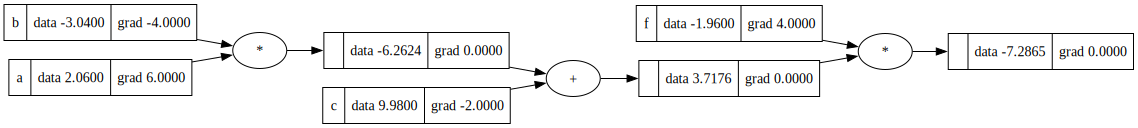

In [16]:
draw_dot(L)

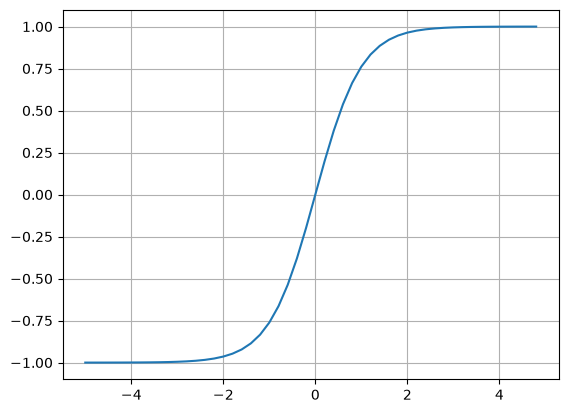

In [17]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid();

Now we are going to create a neuron and do the backpropagation on it.

In [18]:
# inputs 
x1 = Value(2.0,label="x1")
x2 = Value(0.0,label="x2")
# weights 
w1=Value(-3.0,label="w1")
w2=Value(1.0,label="w2")
#bias of the neuron
b=Value(6.8813735870195432,label="b")
# weighted sum with bias i.e x1w1 + x2w2 + b
x1w1 = x1*w1 ; x1w1.label = "x1*w1" 
x2w2 = x2*w2 ; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2  ; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b ; n.label = "n"
o = n.tanh() ; o.label = "o"



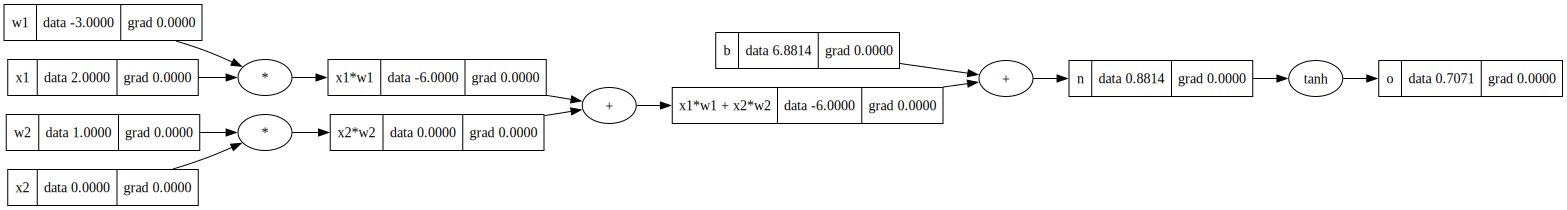

In [19]:
draw_dot(o)

From here the backpropagation starts.
The gradient of o w.r.t o is 1. so, the below code is showing do/do=1.

In [20]:
o.grad= 1.0   

o=tanh(n)
do/dn = 1-tanh(n) ** 2
do/dn = 1-o ** 2
and do/dn = 1-0.7071**2 = 0.49999999 = 0.5

In [21]:
n.grad = 0.5

Now Since we encountered a plus node it will distribute the gradient of previous to next ones (from right to left) <br>
or by derivation it will be - do/dx1w1x2w2 = do/dn * dn/dx1w1x2w2 = 0.5 (do it bro by yourself on a notebook move your lazy body).<br> and same for b also . 

In [22]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

Now same here also is plus so use the same trick ...just move the previous grad to other.

In [23]:
x1w1.grad = 0.5
x2w2.grad = 0.5


By doing manual derivation we can say that the following

In [24]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [25]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

Here , as we have defined _backward function for doing the backprop,will stop doing the manual taking derivative and doing backprop we will use our backprop function 

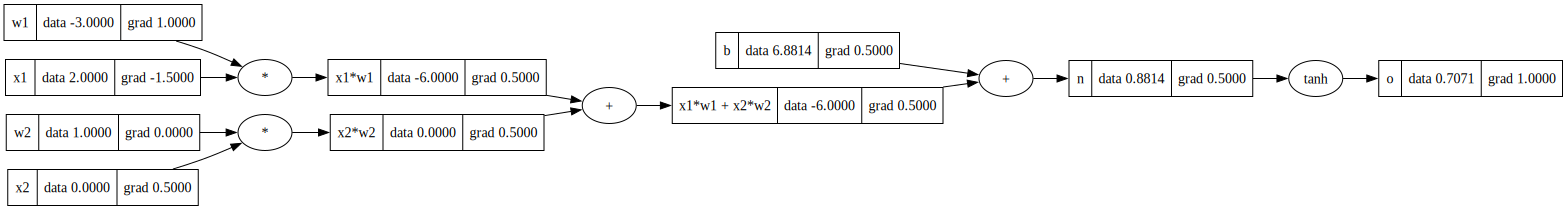

In [26]:
draw_dot(o)  

In [27]:
o.grad = 1.0 # we will define the first to start 

In [28]:
o._backward()

In [29]:
n._backward()

In [30]:
b._backward()
x1w1x2w2._backward() # as there function is defined to do nothing (lamda:None)

In [31]:
x2w2._backward()
x1w1._backward()

In [32]:
# we will now get rid of calling ._backward function again and again.
# We will do this by using Topological sort ( one way search in a graph )
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[value(data=1.0),
 value(data=0.0),
 value(data=0.0),
 value(data=-3.0),
 value(data=2.0),
 value(data=-6.0),
 value(data=-6.0),
 value(data=6.881373587019543),
 value(data=0.8813735870195432),
 value(data=0.7071067811865476)]

In [33]:
# hide this in value class.
#o.grad = 1.0
#topo = []
#visited = set()
#def build_topo(v):
#    if v not in visited:
#        visited.add(v)
#        for child in v._prev:
#            build_topo(child)
#        topo.append(v)
#build_topo(o)
#for node in reversed(topo):
#   node._backward()  

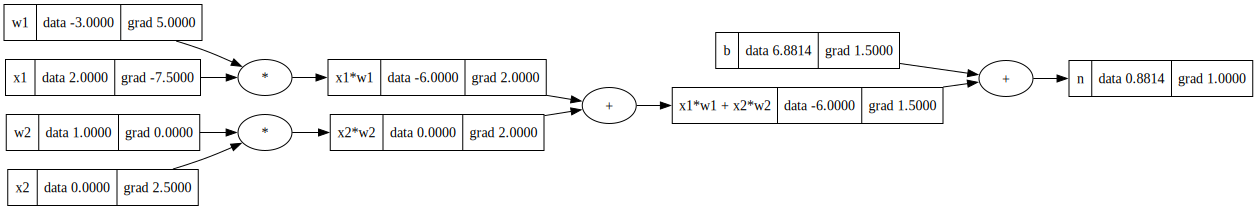

In [34]:
draw_dot(n)

In [35]:
o.backward()


Now we have a single function for backpropagation but there is a little problem it will not work on a certain type of problem 

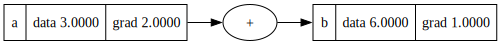

In [36]:
# the problem is 
a = Value(3.0,label="a")
b = a + a ;b.label = "b"
b.backward() # a.grad (db/da) should be 2 but it will come to be 1
draw_dot(b)

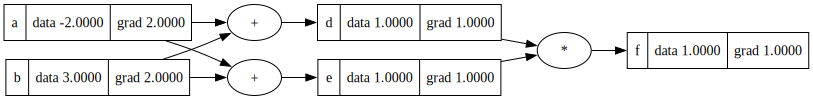

In [37]:
# another example is 
a = Value(-2.0, label="a")
b = Value(3.0, label="b")
d = a + b ; d.label="d"
e = a + b ; e.label="e"
f = d * e ; f.label="f"

f.backward()

draw_dot(f)
# the problem is the re use of the one variable which overwrites the value of self and other in value class
#so the solution is to accumulate it (multivariate variable derivative). Accumalate means carry fotrward like - 1,2,(2+1)=3,(3+3)=6,(4+6)=10. here we are accumulating the result further in the counting.

#THE PROBLEM WAS -

# class Value:
#     def __init__(self,data,_children=(),_op="",label=""):
#         self.data=data
#         self._prev=set(_children)
#         self._op=_op
#         self.label=label
#         self.grad=0.0
#         self._backward = lambda: None # its a func do nothing

#     def __repr__(self):
#         return f"value(data={self.data})"
    
#     def __add__(self,other):
#         out=Value(self.data+other.data,(self,other),"+")

#         def _backward():
#             self.grad = 1.0 * out.grad        the accumulation is not done
#             other.grad = 1.0 * out.grad       the accumulation is not done
#         out._backward = _backward
#         return out

#     def __mul__(self,other):
#         out=Value(self.data*other.data,(self,other),"*")

#         def _backward():
#             self.grad = other.data * out.grad     the accumulation is not done
#             other.grad = self.data * out.grad     the accumulation is not done
#         out._backward = _backward
#         return out
    
#     def tanh(self):
#         x = self.data
#         t = (math.exp(2*x) -1)/(math.exp(2*x) + 1)
#         out = Value(t, (self, ), "tanh")

#         def _backward():
#             self.grad = (1-t**2) * out.grad   the accumulation is not done
#         out._backward = _backward
#         return out
    
#     def backward(self):
       
#         topo = []
#         visited = set()
#         def build_topo(v):
#             if v not in visited:
#                 visited.add(v)
#                 for child in v._prev:
#                     build_topo(child)
#                 topo.append(v)
#         build_topo(self)
#         self.grad = 1.0
#         for node in reversed(topo):
#             node._backward()

   

# a=Value(2.0,label="a")
# b=Value(-3.0,label="b")
# c=Value(10.0,label="c")
# e=a*b; e.label="e"
# d=e+c; d.label="d"
# f=Value(-2.0,label="f")
# L=d*f;L.label="L"
# #d=a*b +c # this work like a.__mul__(b).__add__(c)
# L

# THE SOLUTION IS -


# class Value:
#     def __init__(self,data,_children=(),_op="",label=""):
#         self.data=data
#         self._prev=set(_children)
#         self._op=_op
#         self.label=label
#         self.grad=0.0
#         self._backward = lambda: None # its a func do nothing

#     def __repr__(self):
#         return f"value(data={self.data})"
    
#     def __add__(self,other):
#         out=Value(self.data+other.data,(self,other),"+")

#         def _backward():
#             self.grad += 1.0 * out.grad       the accumulation is  done
#             other.grad += 1.0 * out.grad      the accumulation is  done
#         out._backward = _backward
#         return out

#     def __mul__(self,other):
#         out=Value(self.data*other.data,(self,other),"*")

#         def _backward():
#             self.grad += other.data * out.grad    the accumulation is  done
#             other.grad += self.data * out.grad    the accumulation is done
#         out._backward = _backward
#         return out
    
#     def tanh(self):
#         x = self.data
#         t = (math.exp(2*x) -1)/(math.exp(2*x) + 1)
#         out = Value(t, (self, ), "tanh")

#         def _backward():
#             self.grad += (1-t**2) * out.grad      the accumulation is  done
#         out._backward = _backward
#         return out
    
#     def backward(self):
       
#         topo = []
#         visited = set()
#         def build_topo(v):
#             if v not in visited:
#                 visited.add(v)
#                 for child in v._prev:
#                     build_topo(child)
#                 topo.append(v)
#         build_topo(self)
#         self.grad = 1.0
#         for node in reversed(topo):
#             node._backward()

   

# a=Value(2.0,label="a")
# b=Value(-3.0,label="b")
# c=Value(10.0,label="c")
# e=a*b; e.label="e"
# d=e+c; d.label="d"
# f=Value(-2.0,label="f")
# L=d*f;L.label="L"
# #d=a*b +c # this work like a.__mul__(b).__add__(c)
# L


In [38]:
a=Value(2.0)
a+1


value(data=3.0)

In [39]:
class Value:
    def __init__(self,data,_children=(),_op="",label=""):
        self.data=data
        self._prev=set(_children)
        self._op=_op
        self.label=label
        self.grad=0.0
        self._backward = lambda: None # its a func do nothing

    def __repr__(self):
        return f"value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),"+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),"*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self,other):
        return self * other
    
    def __pow__(self,other):
        assert isinstance(other,(int,float)), "only supporting int/float powers for now"
        out = Value(self.data**other,(self,),f"**{other}")

        def _backward():
            self.grad +=  other * (self.data**(other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self,other):
        return self*other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self,other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), "exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward 
        return out
    
    def backward(self):
       
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

   

a=Value(2.0,label="a")
b=Value(-3.0,label="b")
c=Value(10.0,label="c")
e=a*b; e.label="e"
d=e+c; d.label="d"
f=Value(-2.0,label="f")
L=d*f;L.label="L"
#d=a*b +c # this work like a.__mul__(b).__add__(c)
L

value(data=-8.0)

In [40]:
a=Value(2.0)
a*2

value(data=4.0)

Now does the 2 * a works ??? No its not ,because by doing <br> a * 2 is doing a._mul_(2) so it will work but for <br> 2 * a is like 2._mul(a) which is not happening because of operand type .
<br> <br>
now for 2*a python will check if there is a way to multiply a*2 so for this it will check if there is a function called _rmul (reverse multiply i guess) and if there is it will do a * 2 .

In [41]:
a = Value(2.0) 
2*a

value(data=4.0)

In [42]:
a = Value(2.0)
a.exp()

value(data=7.38905609893065)

The division a/b can also be done like - a * b**-1<br>
so we will do the division in this way.

In [43]:
a = Value(2.0)
b = Value(4.0)
print(a/b)
print(a-b)

value(data=0.5)
value(data=-2.0)


In [44]:
# inputs 
x1 = Value(2.0,label="x1")
x2 = Value(0.0,label="x2")
# weights 
w1=Value(-3.0,label="w1")
w2=Value(1.0,label="w2")
#bias of the neuron
b=Value(6.8813735870195432,label="b")
# weighted sum with bias i.e x1w1 + x2w2 + b
x1w1 = x1*w1 ; x1w1.label = "x1*w1" 
x2w2 = x2*w2 ; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2  ; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b ; n.label = "n"
# -------------
e = (2*n).exp()
o = (e-1) / (e + 1)
# -------------
o.label = "o"
o.backward()

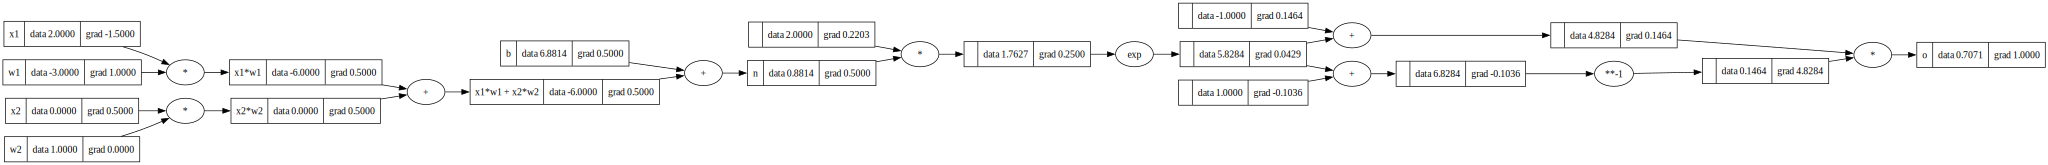

In [45]:
draw_dot(o)

In [46]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [47]:
import torch

In [48]:
x1 = torch.Tensor([2.0]).double()               ;x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ;x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ;w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ;w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ;b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("---")
print("x2", x2.grad.item())
print("w2",w2.grad.item())
print("x1",x1.grad.item())
print("w1",w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [49]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [50]:
o.item()

0.7071066904050358

In [51]:
torch.Tensor([[[1, 2, 3], [4, 5, 6]]])

tensor([[[1., 2., 3.],
         [4., 5., 6.]]])

In [52]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [53]:
import random

In [54]:
class Neuron :

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self,x):
        # w*x + b
        act = sum((wi*xi for wi, xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        # return params
        # Alternative for this is 
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
   



    


In [55]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4, 4, 1])
n(x)

value(data=-0.8413070718042679)

In [56]:
len(n.parameters())

41

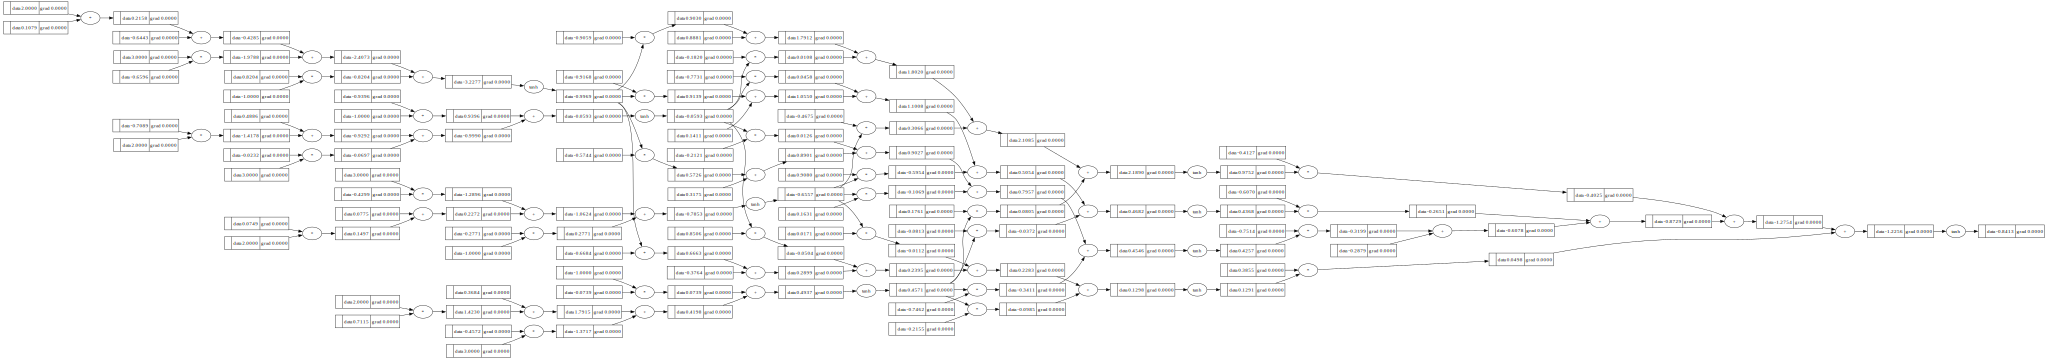

In [57]:
draw_dot(n(x))

In [58]:
xs = [
    [2.0, 3.0, -1.0 ],
    [3.0, -1.0, 0.5],
    [0.5,  1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[value(data=-0.8413070718042679),
 value(data=-0.6871082103069556),
 value(data=-0.9118858949153844),
 value(data=-0.7431270917885167)]

In [59]:
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)], Value(0.0))
loss

value(data=6.534569158375678)

In [60]:
for p in n.parameters():
    p.grad = 0.0
loss.backward()


In [61]:
n.layers[0].neurons[0].w[0].grad

0.5058377861486396

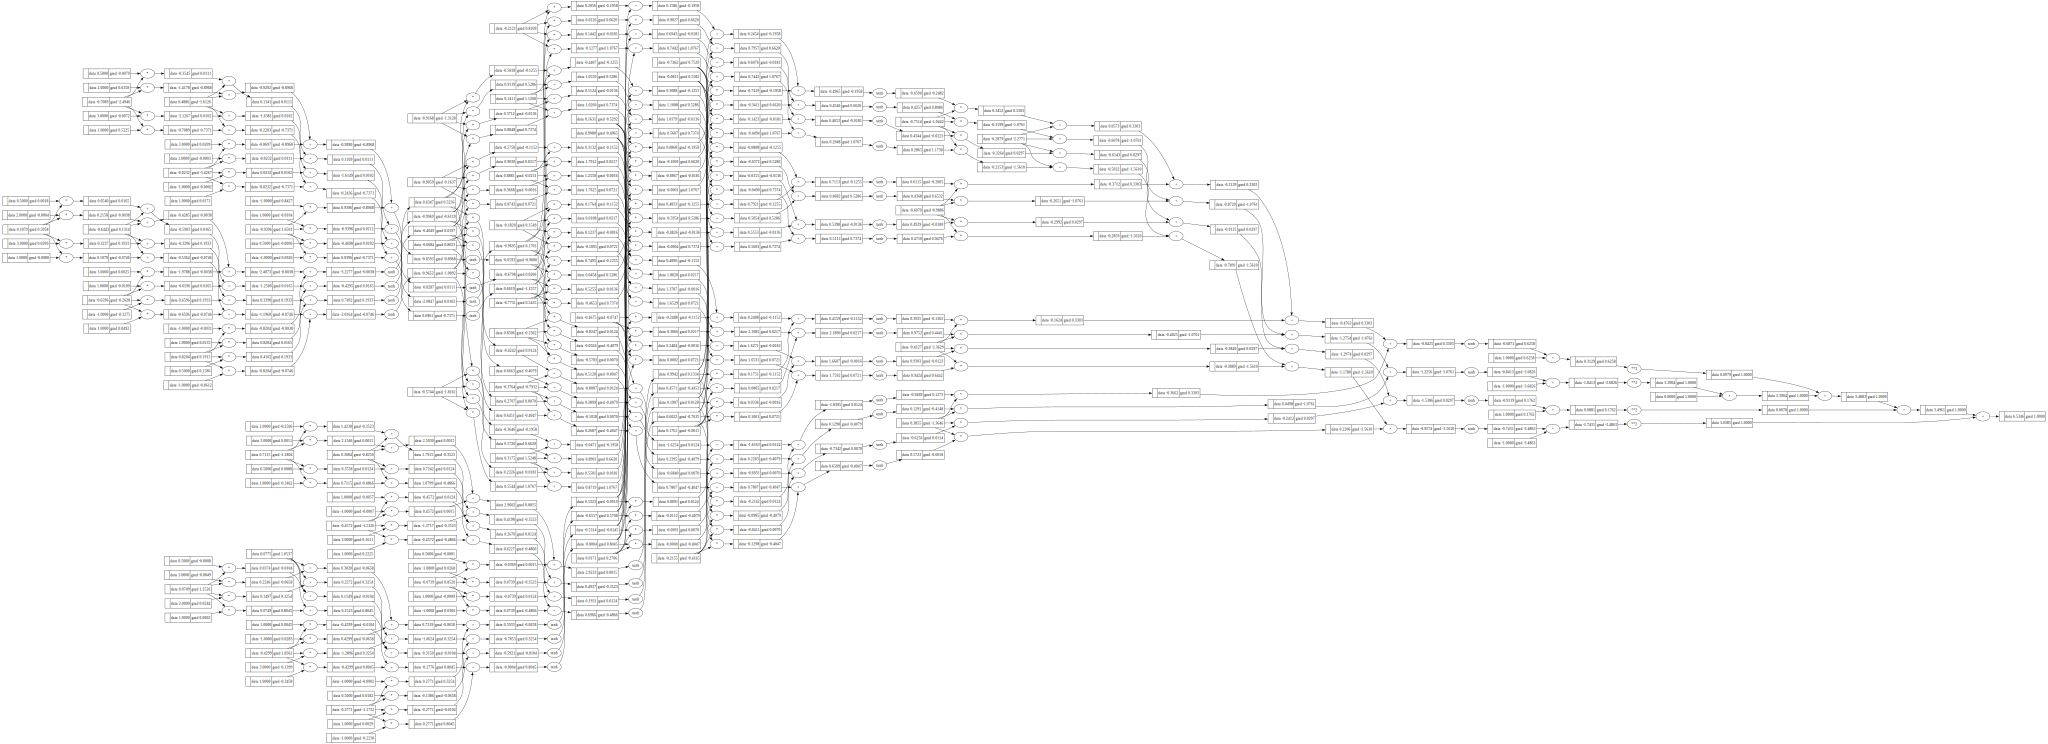

In [62]:
draw_dot(loss)

In [63]:
n.layers[0].neurons[0].w[0].data

0.1079036318708424

In [64]:
for p in n.parameters():
    p.data += -0.1 * p.grad

In [65]:
n.layers[0].neurons[0].w[0].data

0.05731985325597844

In [66]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)], Value(0.0))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update 
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k,loss.data)


0 0.8403956868447011
1 0.4139408280304726
2 0.2835002759688349
3 0.21350614165609433
4 0.16960158875782547
5 0.13977765632674613
6 0.11834126048473312
7 0.10226757730243653
8 0.0898123798777933
9 0.07990450440375323
10 0.07185234211039596
11 0.06519075082851347
12 0.05959611711911454
13 0.054836764538342006
14 0.05074273166758747
15 0.0471866695432448
16 0.04407138110712845
17 0.0413214670662394
18 0.038877588065344984
19 0.036692438607390875


In [67]:
ypred

[value(data=0.9191334788695263),
 value(data=-0.9267428928098601),
 value(data=-0.8902810054612791),
 value(data=0.8870921488505338)]

After this we can fully understand the micrograd as this is the whole builiding block of the micrograd, there might be some difference but they will be very understandable like - instead of tanh there will be Relu activation function etc etc .

<h1> THE END </H1>